In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('raw/raw_device_data.csv')
df

,time,result,table,controller,site,power_factor_avg,units,current_avg,apparent_power_demand,apparent_power_total,apparent_energy,power_l1,power_l2,power_l3
0,2026-02-10 07:15:00+00:00,0.0,2.000000,0.0,0.0,0.26,0.0,5.450000,3.820000,3.821340,15441.800000,0.997129,-0.966264,0.950757
1,2026-02-10 07:30:00+00:00,0.0,2.000000,0.0,0.0,0.26,0.0,5.441250,3.811250,3.808032,15442.700000,0.998546,-0.964310,0.952342
2,2026-02-10 07:45:00+00:00,0.0,2.062500,0.0,0.0,0.26,0.0,5.440000,3.800000,3.805320,15443.650000,0.997627,-0.964680,0.950534
3,2026-02-10 08:00:00+00:00,0.0,2.000000,0.0,0.0,0.26,0.0,5.441429,3.801429,3.808286,15444.414286,0.993162,-0.962110,0.948484
4,2026-02-10 08:15:00+00:00,0.0,2.000000,0.0,0.0,0.26,0.0,5.440000,3.815000,3.812155,15445.250000,0.993512,-0.962323,0.949391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2026-02-10 22:45:00+00:00,0.0,2.000000,0.0,0.0,0.39,0.0,1.470000,1.050000,1.048320,15461.266667,0.417971,-0.284931,0.277591
63,2026-02-10 23:00:00+00:00,0.0,2.117647,0.0,0.0,0.39,0.0,1.470000,1.050000,1.054090,15461.433333,0.417548,-0.285001,0.277795
64,2026-02-10 23:15:00+00:00,0.0,2.000000,0.0,0.0,0.39,0.0,1.470000,1.055000,1.054195,15461.550000,0.418451,-0.285383,0.278069
65,2026-02-10 23:30:00+00:00,0.0,2.000000,0.0,0.0,0.39,0.0,1.507500,1.060000,1.082288,15461.675000,0.430121,-0.296213,0.289482


In [19]:
df.columns

Index(['time', 'result', 'table', 'controller', 'site', 'power_factor_avg',
       'units', 'current_avg', 'apparent_power_demand', 'apparent_power_total',
       'apparent_energy', 'power_l1', 'power_l2', 'power_l3'],
      dtype='object')

In [3]:
# ---- Clean & standardize time ----
df['time'] = pd.to_datetime(df['time'])

In [4]:
# Sort by time (very important in industry)
df = df.sort_values('time').reset_index(drop=True)


In [5]:
print("Raw extracted shape:", df.shape)
print(df.head())

Raw extracted shape: (67, 14)
                       time  result   table  controller  site  \
0 2026-02-10 07:15:00+00:00     0.0  2.0000         0.0   0.0   
1 2026-02-10 07:30:00+00:00     0.0  2.0000         0.0   0.0   
2 2026-02-10 07:45:00+00:00     0.0  2.0625         0.0   0.0   
3 2026-02-10 08:00:00+00:00     0.0  2.0000         0.0   0.0   
4 2026-02-10 08:15:00+00:00     0.0  2.0000         0.0   0.0   

   power_factor_avg  units  current_avg  apparent_power_demand  \
0              0.26    0.0     5.450000               3.820000   
1              0.26    0.0     5.441250               3.811250   
2              0.26    0.0     5.440000               3.800000   
3              0.26    0.0     5.441429               3.801429   
4              0.26    0.0     5.440000               3.815000   

   apparent_power_total  apparent_energy  power_l1  power_l2  power_l3  
0              3.821340     15441.800000  0.997129 -0.966264  0.950757  
1              3.808032     15442.70

In [7]:
# Keep time + only numeric sensor columns
df_raw = df.copy()
df_ahu = df_raw.select_dtypes(include=['float64', 'int64'])
df_ahu.insert(0, 'time', df_raw['time'])

print("Raw AHU dataframe shape:", df_ahu.shape)
print(df_ahu.head())

Raw AHU dataframe shape: (67, 14)
                       time  result   table  controller  site  \
0 2026-02-10 07:15:00+00:00     0.0  2.0000         0.0   0.0   
1 2026-02-10 07:30:00+00:00     0.0  2.0000         0.0   0.0   
2 2026-02-10 07:45:00+00:00     0.0  2.0625         0.0   0.0   
3 2026-02-10 08:00:00+00:00     0.0  2.0000         0.0   0.0   
4 2026-02-10 08:15:00+00:00     0.0  2.0000         0.0   0.0   

   power_factor_avg  units  current_avg  apparent_power_demand  \
0              0.26    0.0     5.450000               3.820000   
1              0.26    0.0     5.441250               3.811250   
2              0.26    0.0     5.440000               3.800000   
3              0.26    0.0     5.441429               3.801429   
4              0.26    0.0     5.440000               3.815000   

   apparent_power_total  apparent_energy  power_l1  power_l2  power_l3  
0              3.821340     15441.800000  0.997129 -0.966264  0.950757  
1              3.808032     1544

15 min resampling 

In [9]:
df_ahu = df_ahu.set_index('time')

In [10]:
#now resample
df_resampled = df_ahu.resample('15T').mean()


C:\Users\karki\AppData\Local\Temp\ipykernel_15716\48082478.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df_ahu.resample('15T').mean()


In [11]:
print("Resampled shape:", df_resampled.shape)
print(df_resampled.head(10))


Resampled shape: (67, 13)
                           result     table  controller  site  \
time                                                            
2026-02-10 07:15:00+00:00     0.0  2.000000         0.0   0.0   
2026-02-10 07:30:00+00:00     0.0  2.000000         0.0   0.0   
2026-02-10 07:45:00+00:00     0.0  2.062500         0.0   0.0   
2026-02-10 08:00:00+00:00     0.0  2.000000         0.0   0.0   
2026-02-10 08:15:00+00:00     0.0  2.000000         0.0   0.0   
2026-02-10 08:30:00+00:00     0.0  2.000000         0.0   0.0   
2026-02-10 08:45:00+00:00     0.0  2.058824         0.0   0.0   
2026-02-10 09:00:00+00:00     0.0  2.117647         0.0   0.0   
2026-02-10 09:15:00+00:00     0.0  2.000000         0.0   0.0   
2026-02-10 09:30:00+00:00     0.0  2.000000         0.0   0.0   

                           power_factor_avg  units  current_avg  \
time                                                              
2026-02-10 07:15:00+00:00              0.26    0.0     5.45

In [12]:
missing_counts = df_resampled.isna().sum()
print("Missing values per column:\n")
print(missing_counts[missing_counts > 0])


Missing values per column:

Series([], dtype: int64)


In [13]:
#to check time gap
print("\nTime gaps:")
print(df_resampled.index.to_series().diff().value_counts())



Time gaps:
time
0 days 00:15:00    66
Name: count, dtype: int64


<Axes: xlabel='time'>

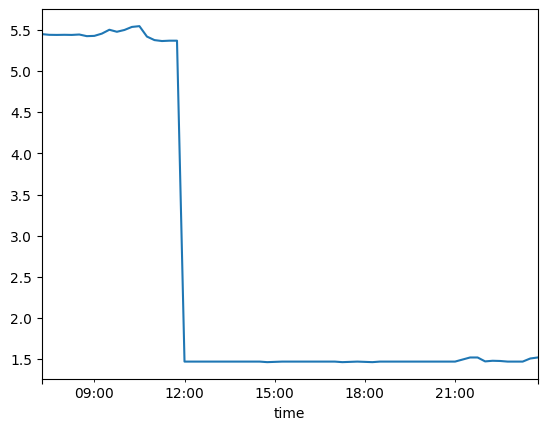

In [18]:
#is the machine drawing more current over time ?
df_resampled['current_avg'].plot()
